# Dangerosité des passes — Coupe du monde 2022

**Question :** quelles passes mettent vraiment l'adversaire en danger, et peut-on le mesurer de façon fiable ?

**Approche :** pour chaque passe réussie du tournoi, estimer la probabilité que l'équipe tire dans les 15 secondes qui suivent (même possession), à partir de ce qu'on sait *au moment de la passe* : où elle part, où elle arrive, et la position des joueurs (données StatsBomb 360).

Ce notebook présente les résultats. Le pipeline complet (téléchargement → variables → modèle) est dans `construire_donnees.py` et le dossier `passes/`.

| Étape | Fichier |
|---|---|
| Téléchargement StatsBomb | `passes/donnees.py` |
| Variables de chaque passe (géométrie + 360) | `passes/variables.py` |
| Modèle, validation, importance | `passes/modele.py` |
| Application interactive | `app_passes.py` |


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
BLEU, VERT, ROUGE, GRIS = "#1f8fbf", "#2fa37a", "#d9534f", "#8a94a6"

passes = pd.read_parquet("data/passes.parquet")
matchs = pd.read_parquet("data/matchs.parquet")
minutes = pd.read_parquet("data/minutes.parquet")
rapport = json.load(open("data/rapport_modele.json", encoding="utf-8"))

print(f"{len(passes):,} passes réussies avec image 360, {passes.match_id.nunique()} matchs")
print(f"Couverture 360 : {rapport['couverture_360']:.0%} des passes réussies")
print(f"Passes suivies d'un tir dans les 15 s : {passes.tir_15s.mean():.1%}")

47,329 passes réussies avec image 360, 64 matchs
Couverture 360 : 84% des passes réussies
Passes suivies d'un tir dans les 15 s : 6.7%


## 1. Les données

- **Événements StatsBomb** : chaque passe avec son point de départ, son point d'arrivée, sa technique, la phase de jeu.
- **StatsBomb 360** : au moment de chaque action, la position de tous les joueurs visibles à l'image TV.
- Coordonnées converties en **mètres (105 × 68)** ; l'équipe qui passe attaque toujours vers la droite.

Quelques variables construites pour chaque passe :

In [2]:
colonnes = ["joueur", "receveur", "equipe", "minute", "dist_but_fin", "angle_but_fin", "adv_elimines",
            "defenseurs_restants", "derriere_defense", "dist_adv_fin", "tir_15s"]
passes.sort_values("danger", ascending=False)[colonnes].head(8).round(1)

,joueur,receveur,equipe,minute,dist_but_fin,angle_but_fin,adv_elimines,defenseurs_restants,derriere_defense,dist_adv_fin,tir_15s
3681,Kaoru Mitoma,Ao Tanaka,Japon,50,1.2,145.399994,0,0,-0.2,2.0,True
2376,Thorgan Hazard,Romelu Lukaku,Belgique,89,3.2,100.099998,1,0,1.0,3.0,True
15035,Christian Eriksen,Andreas Christensen,Danemark,69,3.4,95.900002,0,0,0.6,2.7,True
36050,Vinícius Júnior,Raphinha,Brésil,46,4.4,78.099998,0,0,3.0,2.9,False
13567,Antoine Griezmann,Kylian Mbappé,France,85,3.5,93.400002,7,0,6.9,6.7,True
27345,César Montes,Henry Martín,Mexique,46,2.9,103.400002,4,0,1.4,2.0,True
36477,Raphinha,Bremer,Brésil,89,3.5,92.400002,0,0,0.0,1.3,True
40639,Abdelhamid Sabiri,Romain Saïss,Maroc,72,3.5,94.300003,7,0,1.4,2.0,True


## 2. Le danger dépend d'abord de l'endroit où arrive la passe

Avant toute modélisation, la fréquence de tir selon la distance au but montre un effet très fort : c'est la référence à battre.

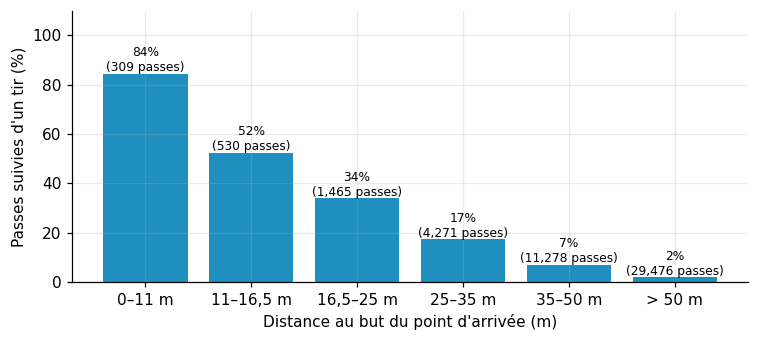

In [3]:
bornes = [0, 11, 16.5, 25, 35, 50, 120]
etiquettes = ["0–11 m", "11–16,5 m", "16,5–25 m", "25–35 m", "35–50 m", "> 50 m"]
tranches = pd.cut(passes["dist_but_fin"], bornes, labels=etiquettes)
taux = passes.groupby(tranches, observed=True)["tir_15s"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(etiquettes, taux["mean"] * 100, color=BLEU)
for i, (t, n) in enumerate(zip(taux["mean"], taux["size"])):
    ax.text(i, t * 100 + 1, f"{t:.0%}\n({n:,} passes)", ha="center", fontsize=8)
ax.set_xlabel("Distance au but du point d'arrivée (m)")
ax.set_ylabel("Passes suivies d'un tir (%)")
ax.set_ylim(0, taux["mean"].max() * 130)
plt.tight_layout()

## 3. Le contexte 360 : l'intuition ne suffit pas

On s'attendrait à ce qu'à distance égale, une passe qui arrive **dans le dos du dernier défenseur** ou avec **peu de défenseurs entre le ballon et le but** soit plus souvent suivie d'un tir. Regardons les passes arrivant entre 16,5 et 30 m du but :

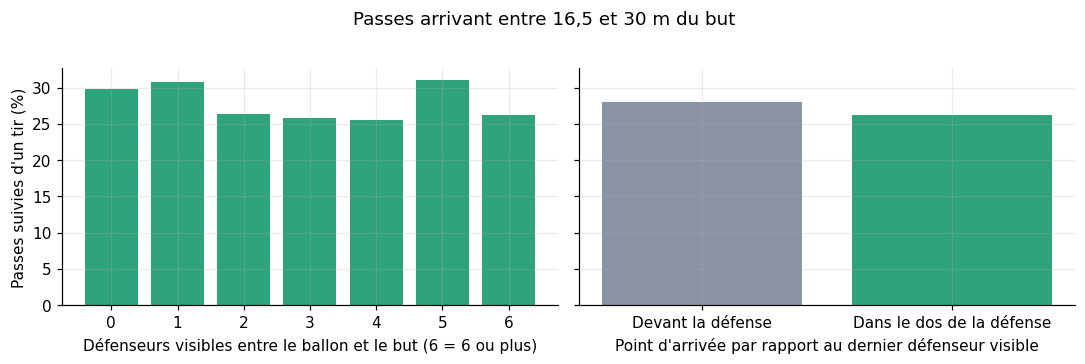

In [4]:
zone = passes[passes["dist_but_fin"].between(16.5, 30)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)

restants = zone.groupby(zone["defenseurs_restants"].clip(upper=6))["tir_15s"].mean() * 100
axes[0].bar(restants.index.astype(str), restants.values, color=VERT)
axes[0].set_xlabel("Défenseurs visibles entre le ballon et le but (6 = 6 ou plus)")
axes[0].set_ylabel("Passes suivies d'un tir (%)")

dos = zone.groupby(zone["derriere_defense"] > 0)["tir_15s"].mean() * 100
axes[1].bar(["Devant la défense", "Dans le dos de la défense"], dos.values, color=[GRIS, VERT])
axes[1].set_xlabel("Point d'arrivée par rapport au dernier défenseur visible")
fig.suptitle("Passes arrivant entre 16,5 et 30 m du but", y=1.02)
plt.tight_layout()

**Les données ne confirment pas l'intuition, du moins pas directement.** Pris seuls, ces indicateurs ne séparent pas les passes dangereuses : les effets bruts sont faibles et brouillés. Plusieurs raisons possibles : une passe dans le dos de la défense est souvent plus longue et plus difficile à contrôler, et les défenseurs hors du champ de la caméra ne sont pas comptés.

C'est pourquoi l'apport du 360 se mesure de la seule façon fiable : comparer, en validation, un modèle **avec** et **sans** ces variables (section suivante).

## 4. Modèle et validation

- **Cible :** tir de la même équipe, dans la même possession, dans les 15 secondes.
- **Validation croisée groupée par match** (5 plis) : un match n'est jamais à la fois dans l'apprentissage et dans le test. Toutes les probabilités utilisées ensuite sont des prédictions hors échantillon.
- **Comparaison** avec la première version du projet (formule à poids fixés à la main) et avec des références simples.
- Les intervalles de confiance du gain d'AUC sont obtenus par **bootstrap sur les matchs** (300 tirages).

In [5]:
lignes = []
for nom, m in rapport["resultats"].items():
    lignes.append({"Approche": nom, "AUC (toutes)": m["auc"],
                   "AUC (dernier tiers)": rapport["resultats_dernier_tiers"][nom]["auc"],
                   "Log loss": m.get("log_loss"), "Brier skill": m.get("brier_skill")})
tableau = pd.DataFrame(lignes).set_index("Approche")
print("Modèle retenu :", rapport["modele_retenu"])
print("Gain du contexte 360 :", rapport["gain_contexte_360"])
print("Gain vs ancienne formule :", rapport["gain_vs_ancienne_formule"])
tableau

Modèle retenu : Régression logistique
Gain du contexte 360 : {'gain': 0.0092, 'ic95': [0.0054, 0.0131]}
Gain vs ancienne formule : {'gain': 0.118, 'ic95': [0.1075, 0.1285]}


,AUC (toutes),AUC (dernier tiers),Log loss,Brier skill
Approche,,,,
Ancienne formule (poids à la main),0.7179,0.5831,NaN,NaN
Distance au but seule,0.8285,0.7424,NaN,NaN
Position seule (sans 360),0.8267,0.7484,0.18785,0.1962
Régression logistique,0.8359,0.7527,0.18558,0.2018
Gradient boosting,0.8342,0.7523,0.18594,0.2002


**Lecture :**
- L'ancienne formule est loin derrière, et quasiment aléatoire dans le dernier tiers (là où se joue le danger).
- La distance au but seule est une référence très solide : la position explique l'essentiel.
- Le contexte 360 apporte un gain **modeste mais significatif** (l'intervalle de confiance ne contient pas 0).
- La régression logistique est retenue : même précision que le gradient boosting, meilleure log loss, plus simple à expliquer.

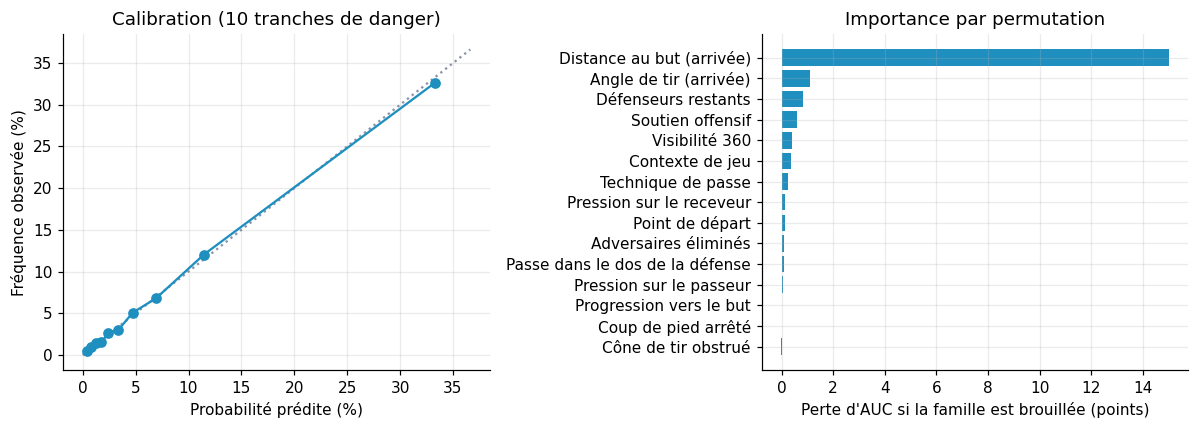

In [6]:
deciles = pd.DataFrame(rapport["deciles"])
importance = pd.Series(rapport["importance"]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lim = deciles[["proba_moyenne", "taux_observe"]].max().max() * 110
axes[0].plot([0, lim], [0, lim], ls=":", color=GRIS)
axes[0].plot(deciles["proba_moyenne"] * 100, deciles["taux_observe"] * 100, "o-", color=BLEU)
axes[0].set_xlabel("Probabilité prédite (%)")
axes[0].set_ylabel("Fréquence observée (%)")
axes[0].set_title("Calibration (10 tranches de danger)")

axes[1].barh(importance.index, importance.values * 100, color=BLEU)
axes[1].set_xlabel("Perte d'AUC si la famille est brouillée (points)")
axes[1].set_title("Importance par permutation")
plt.tight_layout()

## 5. La valeur ajoutée : récompenser aussi la progression

Le danger mesure la **proximité d'un tir**. Une passe qui casse une ligne au milieu de terrain arrive loin du but : elle reste peu dangereuse, même si elle fait beaucoup progresser l'équipe.

Pour la récompenser, un second modèle estime la probabilité de tir **avant la passe**, à partir de la seule situation du passeur (position du ballon, pression, défenseurs entre lui et le but, phase de jeu), sans connaître la destination. Même cible, même validation par match.

> **valeur ajoutée = danger après la passe − probabilité de tir avant la passe** (en points de probabilité)

Elle vaut zéro en moyenne : positive si la passe améliore la situation, négative si elle la dégrade.

Modèle 'avant la passe' : Gradient boosting — AUC 0.7952
Valeur ajoutée moyenne (points) : 0.003 · part de passes positives : 36%
Corrélation (Spearman) avec les adversaires éliminés : {'danger': 0.373, 'valeur_ajoutee': 0.463}


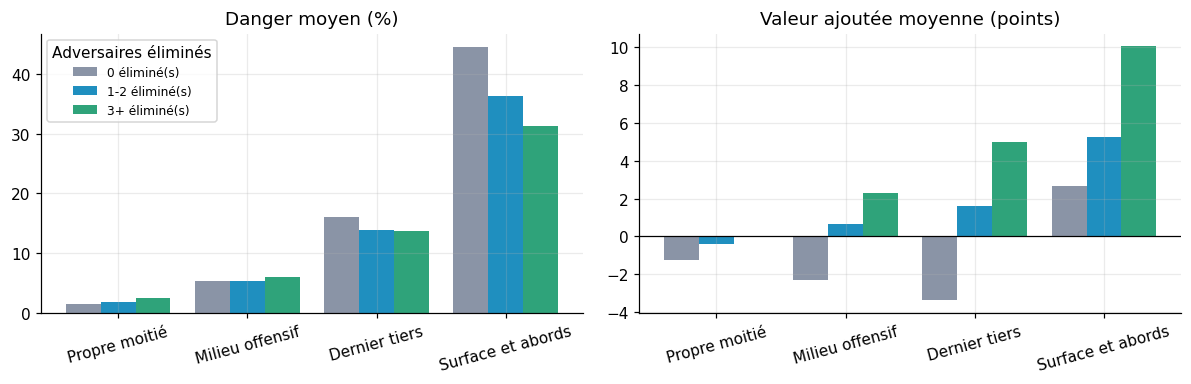

In [7]:
avant, va = rapport["valeur_avant"], rapport["valeur_ajoutee"]
print("Modèle 'avant la passe' :", avant["modele_retenu"], "— AUC", avant["resultats"][avant["modele_retenu"]]["auc"])
print("Valeur ajoutée moyenne (points) :", va["moyenne"], "· part de passes positives :", f"{va['part_positive']:.0%}")
print("Corrélation (Spearman) avec les adversaires éliminés :", va["correlation_adv_elimines"])

par_zone = pd.DataFrame(va["par_zone_et_elimines"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
largeur, zones = 0.27, list(dict.fromkeys(par_zone["zone"]))
for k, (niveau, couleur) in enumerate([("0", GRIS), ("1-2", BLEU), ("3+", VERT)]):
    sous = par_zone[par_zone["elimines"] == niveau].set_index("zone").loc[zones]
    x = np.arange(len(zones)) + (k - 1) * largeur
    axes[0].bar(x, sous["danger"], largeur, color=couleur, label=f"{niveau} éliminé(s)")
    axes[1].bar(x, sous["valeur_ajoutee"], largeur, color=couleur)
axes[0].set_title("Danger moyen (%)")
axes[1].set_title("Valeur ajoutée moyenne (points)")
axes[1].axhline(0, color="black", lw=0.8)
for ax in axes:
    ax.set_xticks(range(len(zones)), zones, rotation=15)
axes[0].legend(title="Adversaires éliminés", fontsize=8)
plt.tight_layout()

**Lecture :** le danger brut classait mal les passes qui éliminent des adversaires (dans le dernier tiers, elles étaient même *moins* dangereuses en moyenne). La valeur ajoutée remet les choses dans l'ordre : dans le dernier tiers, +5,0 points pour 3 adversaires éliminés ou plus contre −3,4 pour aucun ; au milieu offensif, +2,3 contre −2,3.

**Limite :** dans sa propre moitié, même une passe qui élimine 3 adversaires ajoute presque rien (+0,0), car la probabilité de tir dans les 15 secondes y reste très faible avant comme après. Pour valoriser la relance, il faudrait une cible à plus long terme (par exemple, un tir avant la fin de la possession).

## 6. Ce que ça dit du tournoi

### Les passeurs les plus dangereux (jeu courant, au moins 270 minutes)

« Danger créé » = somme des probabilités de tir de toutes les passes d'un joueur, ramenée à 90 minutes.

In [8]:
jeu = passes[passes["type_passe"] == "Jeu courant"]
par_joueur = (jeu.groupby(["joueur_id", "joueur", "equipe"])
              .agg(passes=("danger", "size"), danger=("danger", "sum"),
                   valeur=("valeur_ajoutee", "sum"),
                   tres_dangereuses=("danger", lambda s: (s >= passes["danger"].quantile(0.95)).sum()))
              .reset_index()
              .merge(minutes.groupby("joueur_id")["minutes"].sum().reset_index(), on="joueur_id"))
par_joueur["danger_90"] = par_joueur["danger"] / par_joueur["minutes"] * 90
par_joueur["valeur_90_pts"] = par_joueur["valeur"] * 100 / par_joueur["minutes"] * 90  # en points
top = par_joueur[par_joueur["minutes"] >= 270].nlargest(15, "danger_90")
top[["joueur", "equipe", "minutes", "passes", "tres_dangereuses", "danger_90", "valeur_90_pts"]].round(2)

,joueur,equipe,minutes,passes,tres_dangereuses,danger_90,valeur_90_pts
517,Pedri,Espagne,389.02,369,24,7.58,23.09
184,Joshua Kimmich,Allemagne,303.43,195,18,5.93,136.46
573,Jamal Musiala,Allemagne,283.48,87,27,5.70,-21.97
249,Rodri,Espagne,430.57,593,6,5.49,-60.76
5,Ángel Di María,Argentine,327.38,95,27,4.89,101.01
121,Jordi Alba,Espagne,284.42,256,9,4.88,26.49
161,Lionel Messi,Argentine,791.23,249,56,4.34,69.84
116,Sergio Busquets,Espagne,395.91,236,13,4.28,-44.01
154,Ousmane Dembélé,France,467.61,130,27,4.07,65.39
16,Kevin De Bruyne,Belgique,297.04,77,15,4.06,118.08


### Ceux qui font progresser l'équipe : classement par valeur ajoutée

Le classement change : la valeur ajoutée met en avant des joueurs qui améliorent la situation par leurs passes, pas seulement ceux qui jouent près du but.

In [9]:
par_joueur[par_joueur["minutes"] >= 270].nlargest(15, "valeur_90_pts")[
    ["joueur", "equipe", "minutes", "passes", "danger_90", "valeur_90_pts"]].round(2)

,joueur,equipe,minutes,passes,danger_90,valeur_90_pts
184,Joshua Kimmich,Allemagne,303.43,195,5.93,136.46
16,Kevin De Bruyne,Belgique,297.04,77,4.06,118.08
5,Ángel Di María,Argentine,327.38,95,4.89,101.01
179,Hirving Lozano,Mexique,281.06,30,2.77,89.18
161,Lionel Messi,Argentine,791.23,249,4.34,69.84
333,Raphinha,Brésil,338.70,85,3.36,66.75
154,Ousmane Dembélé,France,467.61,130,4.07,65.39
588,Alistair Johnston,Canada,300.10,95,2.07,58.60
117,Bruno Fernandes,Portugal,396.49,143,3.85,57.53
35,Thiago Silva,Brésil,424.29,277,2.42,56.16


### Danger créé et concédé par équipe

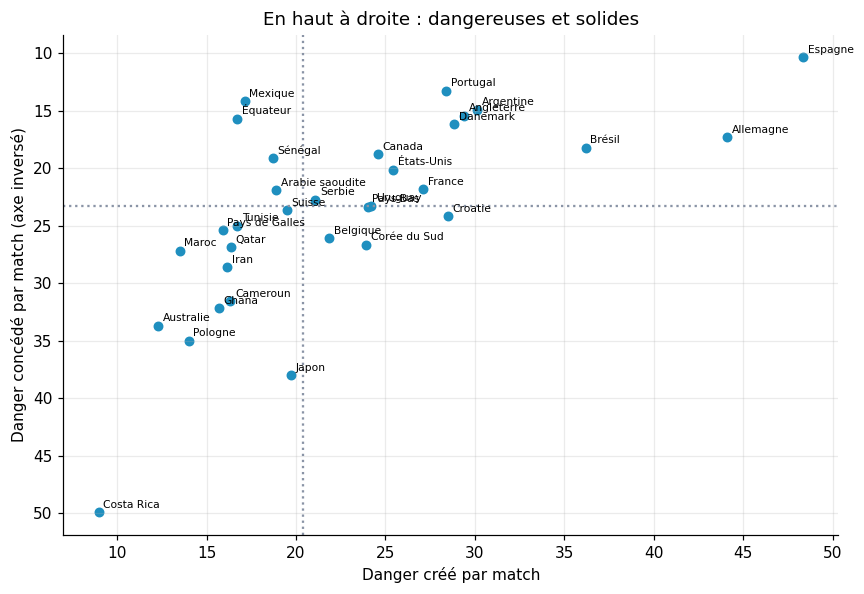

In [10]:
nb_matchs = pd.concat([matchs["domicile"], matchs["exterieur"]]).value_counts()
equipes = pd.DataFrame({"cree": jeu.groupby("equipe")["danger"].sum() / nb_matchs,
                        "concede": jeu.groupby("adversaire")["danger"].sum() / nb_matchs})

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(equipes["cree"], equipes["concede"], color=BLEU, s=30)
for nom, ligne in equipes.iterrows():
    ax.annotate(nom, (ligne["cree"], ligne["concede"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axvline(equipes["cree"].median(), ls=":", color=GRIS)
ax.axhline(equipes["concede"].median(), ls=":", color=GRIS)
ax.invert_yaxis()
ax.set_xlabel("Danger créé par match")
ax.set_ylabel("Danger concédé par match (axe inversé)")
ax.set_title("En haut à droite : dangereuses et solides")
plt.tight_layout()

### Les passes les plus dangereuses de la finale

In [11]:
finale = matchs.loc[matchs["phase"] == "Finale", "match_id"].item()
(passes[passes["match_id"] == finale]
 .nlargest(8, "danger")[["minute", "joueur", "receveur", "equipe", "danger", "tir_15s", "but_15s"]]
 .assign(danger=lambda d: (d["danger"] * 100).round(1)))

,minute,joueur,receveur,equipe,danger,tir_15s,but_15s
20638,35,Alexis MacAllister,Ángel Di María,Argentine,95.4,True,True
20897,67,Antoine Griezmann,Randal Kolo,France,91.8,True,False
21191,122,Gonzalo Montiel,Lautaro Martínez,Argentine,90.1,True,False
20840,59,Ángel Di María,Lionel Messi,Argentine,83.0,True,False
20637,35,Julián Álvarez,Alexis MacAllister,Argentine,82.4,True,True
21131,104,Lionel Messi,Lautaro Martínez,Argentine,79.6,True,False
21137,105,Marcos Acuña,Lautaro Martínez,Argentine,79.1,True,False
20515,16,Rodrigo De Paul,Lionel Messi,Argentine,75.5,True,False


## 7. Limites et pistes

- **Joueurs hors champ :** les données 360 viennent des images TV ; les joueurs hors cadre ne sont pas connus. La variable « adversaires visibles » sert de contrôle.
- **Une photo, pas un film :** positions au moment de la passe, pas de la réception.
- **Un seul tournoi :** tester le modèle entraîné ici sur l'Euro 2024 ou la Ligue 1 (aussi disponibles en 360) serait la prochaine validation.
- **Passes ratées non notées :** un modèle de risque (probabilité de perdre le ballon) compléterait l'analyse, pour juger une passe sur le rapport risque / danger.
- **Cible :** « tir dans les 15 s » est simple et vérifiable ; une variante pondérée par l'xG du tir mesurerait aussi la qualité de l'occasion.